## Classification Trees

A **classification tree** predicts a *category* (yes/no, spam/ham, disease/healthy) instead of a number. Like a regression tree it splits the data with yes/no questions, but each **leaf** predicts a **class** — the majority class of the training samples that land there.

Here we predict whether a patient has **heart disease** from three simple symptoms:

- Does the patient have **chest pain**?
- Do they have **good blood circulation**?
- Are their **arteries blocked**?

To choose the best question at each node, the tree measures how *mixed* the resulting groups are using **Gini impurity**:

$$Gini = 1 - \sum_{k} p_k^2$$

where $p_k$ is the fraction of samples of class $k$ in a node. A **pure** leaf (all one class) has $Gini = 0$. The tree picks the split whose weighted-average Gini is the **lowest** — i.e. the split that separates the classes best.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
# Small patient dataset: 1 = yes, 0 = no
data = pd.DataFrame({
    "chest_pain":        [1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0],
    "good_circulation":  [0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1],
    "blocked_arteries":  [1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0],
    "heart_disease":     [1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0],
})

X = data[["chest_pain", "good_circulation", "blocked_arteries"]]
y = data["heart_disease"]

data

,chest_pain,good_circulation,blocked_arteries,heart_disease
0,1,0,1,1
1,0,1,0,0
2,1,0,1,1
3,1,0,1,1
4,0,1,0,0
5,1,0,1,1
6,0,1,0,0
7,1,1,0,0
8,0,1,0,0
9,0,0,1,1


### Fit the tree

`criterion="gini"` is the default. We cap the depth so the tree stays small and readable instead of splitting until every leaf is a single patient.

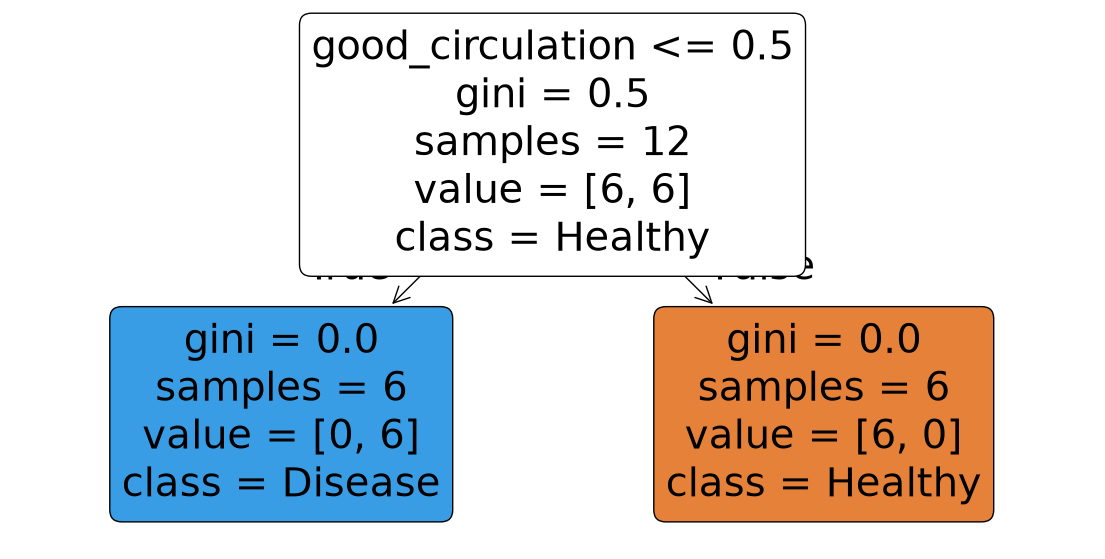

In [3]:
tree = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=0)
tree.fit(X, y)

plt.figure(figsize=(14, 7))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["Healthy", "Disease"],
    filled=True,
    rounded=True,
    precision=2
)
plt.show()

### Reading the tree

Start at the top and answer each yes/no question (`False` goes left, `True` goes right in scikit-learn's layout). Each node shows:

- **`gini`** — how mixed the node is. The root is the most mixed; leaves are the purest.
- **`samples`** — how many training patients reached that node.
- **`value`** — the class counts `[Healthy, Disease]`.
- **`class`** — the majority prediction for that leaf.

The `filled` colouring shades each node toward the class it favours, so you can *see* the tree separating healthy from diseased patients as you go down.

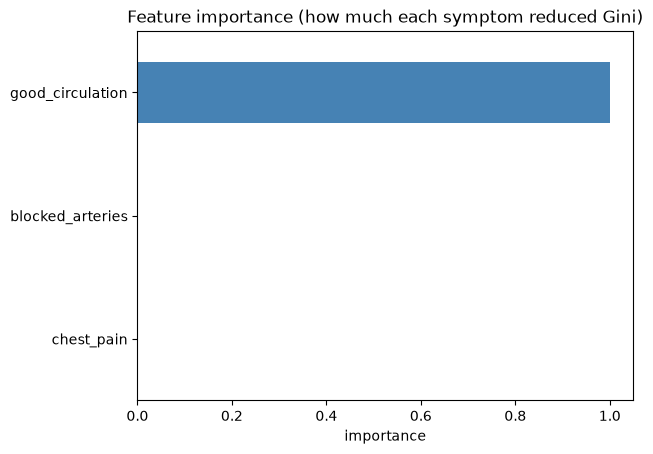

In [4]:
# Which symptom mattered most? Feature importances come straight from the splits
importances = pd.Series(tree.feature_importances_, index=X.columns)
importances.sort_values().plot.barh(color="steelblue")
plt.title("Feature importance (how much each symptom reduced Gini)")
plt.xlabel("importance")
plt.show()

### Predict for new patients

For a new patient we drop their symptoms into the tree, follow the questions to a leaf, and read off the class. `predict_proba` shows how confident the leaf is (the class proportions inside it).

In [5]:
new_patients = pd.DataFrame({
    "chest_pain":        [1, 0],
    "good_circulation":  [0, 1],
    "blocked_arteries":  [1, 0],
})

preds = tree.predict(new_patients)
probs = tree.predict_proba(new_patients)

for i, row in new_patients.iterrows():
    label = "Disease" if preds[i] == 1 else "Healthy"
    print(f"Patient {i+1}: {row.to_dict()}")
    print(f"   -> predicted: {label}  (P(disease) = {probs[i][1]:.2f})\n")

Patient 1: {'chest_pain': 1, 'good_circulation': 0, 'blocked_arteries': 1}
   -> predicted: Disease  (P(disease) = 1.00)

Patient 2: {'chest_pain': 0, 'good_circulation': 1, 'blocked_arteries': 0}
   -> predicted: Healthy  (P(disease) = 0.00)

